In [1]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [2]:
# Cell type fractions
celltype_fraction = {
    "late_MgkPro": 0.05, 
    "EryPro": 0.05
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",
     "il7_[ng_ml]",
     "mcsf_[ng_ml]",
     "ly_cocktail_[ul/well]", 
     # "loss", 
     # "target_ct_loss_std",
     # "target_ct_loss_mean",
     # "ct_prop_total_variance"
]

## Load solutions 

In [3]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                candidate_with_uncertainty_df = pd.read_csv(
                    uncertainty_path
                )

                candidate_with_uncertainty_df["run_name"] = [
                    Path(file).name
                    for file in candidate_with_uncertainty_df[
                        "cfg:paths:dump_dir"
                    ]
                ]

                pure_cell_type_solution_dict[cell_type].append(
                    candidate_with_uncertainty_df
                )

    return pure_cell_type_solution_dict

## Read annotation file

In [4]:
# Read annotation files
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop4.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

In [5]:
bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 100.0),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0),
 'il7_[ng_ml]': (0.0, 20.0),
 'mcsf_[ng_ml]': (0.0, 20.0),
 'ly_cocktail_[ul/well]': (0.0, 15.0)}

### Collect optimized samples 

In [6]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate")
paths_loop = os.listdir(path_to_results)

In [7]:
cell_types = ["late_MgkPro", "EryPro"]

raw_solutions_loop3 = load_pure_cell_type_solutions(
    path_to_results,
    paths_loop,
    cell_types,
    load_uncertainties=False
)

100%|██████████| 6/6 [01:32<00:00, 15.41s/it]


In [8]:
raw_solutions_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop3.items()
}

In [9]:
mgkpro_df = raw_solutions_loop3["late_MgkPro"].reset_index()
erypro_df = raw_solutions_loop3["EryPro"].reset_index()

# Filter solutions

In [10]:
columns_of_interest

['gm-csf_[ng_ml]',
 'tpo_[ng_ml]',
 'sr1_[nm]',
 'um171_[nm]',
 'um729_[µm]',
 'scf_[ng_ml]',
 'butyzamide_[nm]',
 'retinoic_acid_[µm]',
 'ldl_[ng_ml]',
 'il3_[ng_ml]',
 'o2_[%]',
 'days_of_culture',
 'run_name',
 'cfg:constraints:c_scheduler_kwargs:t_warmup',
 'cfg:constraints:c_scheduler_kwargs:vmin',
 'cfg:constraints:c_scheduler_kwargs:vmax',
 'il7_[ng_ml]',
 'mcsf_[ng_ml]',
 'ly_cocktail_[ul/well]']

In [11]:
# Collect filtered and annotated data frames 
filtered_df_mgkpro, annotated_df_mgkpro = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_df},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
)
mgkpro_filtered = filtered_df_mgkpro["late_MgkPro"]

# Collect filtered and annotated data frames 
filtered_df_erypro, annotated_df_erypro = manual_filtering(
    df_dict={"EryPro": erypro_df},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
)
erypro_filtered = filtered_df_erypro["EryPro"]

In [12]:
mgkpro_filtered

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,days_of_culture,run_name,cfg:constraints:c_scheduler_kwargs:t_warmup,cfg:constraints:c_scheduler_kwargs:vmin,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],late_MgkPro_prop,filtering_step
14850,2.901813,1.120201,0.000000,0.871604,0.060262,0.199011,0.222052,0.762257,0.000000,0.144752,...,12.063356,penalized_all_axes-pure_populations-constant,0.25,5.0,15.0,0.097603,0.145568,1.717761,0.976021,pass
11050,2.031568,1.126672,0.010274,0.370101,0.042324,0.146296,0.344762,1.080329,0.000000,0.159374,...,12.102690,penalized_all_axes-pure_populations-constant,0.00,2.0,10.0,0.158242,0.177364,1.027865,0.975834,pass
18240,3.454402,0.416463,0.000000,0.148695,0.427876,6.651300,36.120712,0.345329,0.007267,0.172964,...,12.029169,penalized_all_axes-pure_populations-constant,0.25,1.0,10.0,1.066366,0.216080,0.007611,0.973366,pass
10900,2.312465,1.358802,0.000000,2.095649,0.132456,0.402110,0.075527,0.712367,0.000000,0.268892,...,12.065746,penalized_all_axes-pure_populations-constant,0.50,2.0,10.0,0.063489,0.229771,1.791848,0.973257,pass
10250,2.574442,1.088460,0.000000,0.429443,0.057049,0.139419,0.295117,1.436346,0.000000,0.088679,...,12.232633,penalized_all_axes-pure_populations-constant,0.25,2.0,15.0,0.168094,0.196441,0.811486,0.972872,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26872,8.707163,2.860080,34.265550,2.860048,0.027906,3.910083,0.061322,0.198821,0.085647,0.067723,...,17.411800,penalized_all_axes-pure_populations-reciprocal,0.10,1.0,15.0,0.047662,0.075620,0.027403,0.050613,pass
16847,9.883328,0.219211,26.201704,0.715825,0.000000,2.117974,15.779774,0.700428,0.028628,0.070233,...,17.476452,penalized_all_axes-pure_populations-constant,0.50,5.0,15.0,0.000000,0.146807,0.000000,0.050489,pass
27372,8.708989,2.855329,34.393616,2.858569,0.026220,3.983648,0.061256,0.200908,0.085265,0.065191,...,17.426199,penalized_all_axes-pure_populations-reciprocal,0.25,2.0,15.0,0.047430,0.074150,0.025030,0.050181,pass
29572,8.759653,2.856038,34.309610,2.987395,0.029853,4.018897,0.060742,0.201457,0.079034,0.070648,...,17.308556,penalized_all_axes-pure_populations-reciprocal,0.10,5.0,15.0,0.049846,0.085234,0.033365,0.050178,pass


In [13]:
erypro_filtered

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,days_of_culture,run_name,cfg:constraints:c_scheduler_kwargs:t_warmup,cfg:constraints:c_scheduler_kwargs:vmin,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],EryPro_prop,filtering_step
16530,10.109734,2.541731,339.11480,0.00000,0.309448,0.032268,0.000000,0.035539,0.000000,5.064236,...,18.302496,penalized_all_axes-pure_populations-constant,0.10,1.0,7.5,0.000000,0.000000,0.000000,0.288063,pass
21830,10.061600,2.515606,357.07605,0.00000,0.278387,0.025285,0.000000,0.032154,0.000000,4.555122,...,18.201221,penalized_all_axes-pure_populations-constant,0.50,2.0,15.0,0.000000,0.000000,0.000000,0.287189,pass
17830,10.071359,2.539294,331.36823,0.00000,0.248614,0.103925,0.000000,0.021684,0.000000,4.680527,...,18.149060,penalized_all_axes-pure_populations-constant,0.10,1.0,10.0,0.000000,0.000000,0.001289,0.285933,pass
17880,10.028824,2.539087,347.11664,0.00000,0.242809,0.092547,0.000000,0.035841,0.000000,4.450637,...,17.949549,penalized_all_axes-pure_populations-constant,0.50,5.0,15.0,0.000000,0.000000,0.000000,0.285802,pass
16280,10.028240,2.539309,336.30023,0.00000,0.239556,0.117825,0.000000,0.027621,0.000000,4.540840,...,17.941114,penalized_all_axes-pure_populations-constant,0.25,2.0,15.0,0.000000,0.000000,0.000674,0.285728,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30570,7.591170,2.821379,722.01074,448.05240,0.242149,0.000000,0.007497,0.064998,0.000000,7.716222,...,19.413263,penalized_all_axes-pure_populations-reciprocal,0.10,2.0,10.0,0.141405,0.000000,0.364654,0.050033,pass
27420,7.394973,2.870264,702.37494,396.31836,0.262734,0.000000,0.012074,0.078591,0.000000,8.894323,...,19.068390,penalized_all_axes-pure_populations-reciprocal,0.25,5.0,10.0,0.151268,0.000000,0.347449,0.050026,pass
30683,7.704694,2.780124,301.79025,961.98380,0.000000,52.396492,0.000000,0.000000,0.031462,0.377999,...,15.326775,penalized_all_axes-pure_populations-reciprocal,0.25,1.0,10.0,0.000000,0.000000,0.030052,0.050020,pass
27630,10.174850,2.667546,225.16399,885.16223,0.089084,37.434402,0.000000,0.108109,0.000000,3.271883,...,14.557993,penalized_all_axes-pure_populations-reciprocal,0.10,2.0,10.0,0.000000,0.000000,0.000000,0.050014,pass


## Check amount of TPO in generations 

MgkPro

<Axes: xlabel='tpo_[ng_ml]', ylabel='Density'>

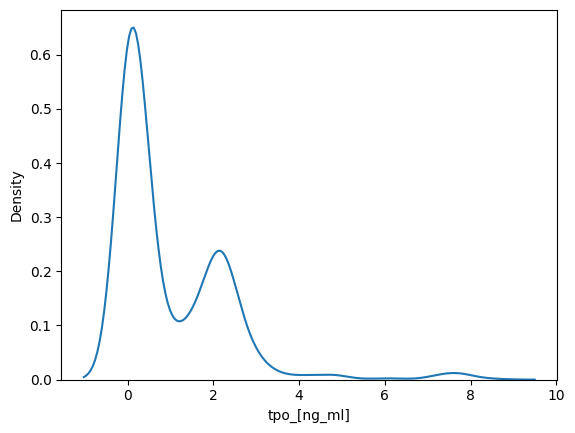

In [14]:
sns.kdeplot(mgkpro_filtered, x="tpo_[ng_ml]")

In [15]:
mgkpro_filtered["tpo_[ng_ml]"].max()

np.float64(8.472145)

EryPro

<Axes: xlabel='tpo_[ng_ml]', ylabel='Density'>

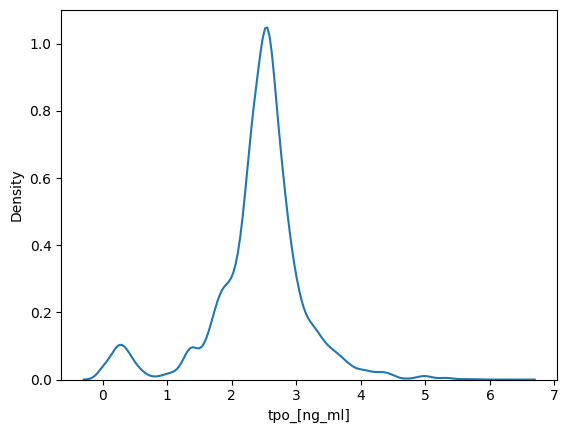

In [16]:
sns.kdeplot(erypro_filtered, x="tpo_[ng_ml]")

In [17]:
erypro_filtered["tpo_[ng_ml]"].max()

np.float64(6.400262)

# Clustering 

### MgkPro

In [18]:
mgkpro_prot = np.log1p(mgkpro_filtered.loc[:, protocol_cols])
late_mgkpro_prop = mgkpro_filtered["late_MgkPro_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


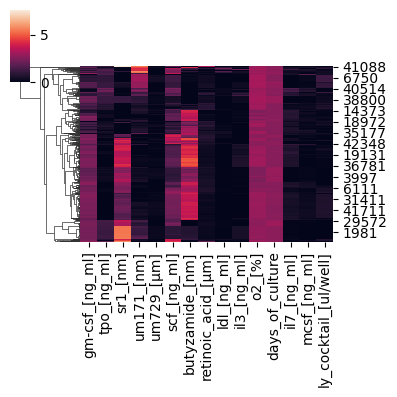

In [19]:
g = sns.clustermap(mgkpro_prot, figsize=(4,4), row_cluster=True, col_cluster=False)

In [20]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 7
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'late_MgkPro_prop': late_mgkpro_prop.values
}, index=mgkpro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['late_MgkPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
5        0.786205    579
4        0.696754    188
7        0.486223      1
2        0.371431     31
3        0.276172      3
1        0.128233      5
6        0.086236    112
       cluster  late_MgkPro_prop
18240        5          0.973366
36548        5          0.969329
19727        5          0.968883
11048        5          0.968560
33317        5          0.967871
...        ...               ...
10247        5          0.051228
34897        5          0.051217
16547        5          0.050894
16847        5          0.050489
4697         5          0.050004

[579 rows x 2 columns]


In [21]:
mgkpro_cl1 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==1].index]
mgkpro_cl1 = mgkpro_cl1.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl1.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
35038,3.255026,2.094822,1880.3599,252.90317,0.0,4.879665,0.0,23.092648,0.0,0.0,14.684956,12.180418,0.0,0.272393,0.0
35088,3.130128,1.993004,1852.8867,246.32567,0.0,4.499290,0.0,23.941776,0.0,0.0,15.014075,12.134026,0.0,0.248359,0.0
39688,3.121015,1.992348,1851.6770,245.60954,0.0,4.492111,0.0,24.006392,0.0,0.0,15.008773,12.139466,0.0,0.250245,0.0


In [22]:
mgkpro_cl2 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==2].index]
mgkpro_cl2 = mgkpro_cl2.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl2.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
37314,0.998721,3.997015,0.0,59.929436,0.000000,10.136994,0.000000,0.000000,0.002950,0.000000,17.092747,17.028334,0.181487,0.604112,0.146363
36364,0.987275,4.041369,0.0,60.553658,0.004653,10.111389,0.000000,0.000000,0.001370,0.000000,17.081371,16.938515,0.193603,0.618046,0.158731
12099,1.859551,2.596672,0.0,218.342940,0.000000,9.868425,0.242246,0.091639,1.520263,0.542497,20.229567,15.004140,0.275702,0.099076,0.352277


In [23]:
mgkpro_cl3 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==3].index]
mgkpro_cl3 = mgkpro_cl3.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl3.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
39616,20.798906,3.270671,0.099068,2.175215,0.0,67.097860,0.0,0.249301,0.0000,0.000000,20.222017,18.021633,0.451980,0.0,0.749028
40697,16.593720,3.222416,0.071090,2.582598,0.0,39.596165,0.0,0.324908,0.0011,0.250319,15.785543,17.128702,0.584996,0.0,0.490582
41366,19.346975,3.037585,0.070269,1.504027,0.0,59.224815,0.0,0.459923,0.0000,0.000000,20.928808,12.936406,0.587995,0.0,1.121301


In [24]:
mgkpro_cl4 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==4].index]
mgkpro_cl4 = mgkpro_cl4.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl4.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
32450,7.214766,2.152420,2.066916,1.513813,0.197395,0.572976,0.0,0.364431,0.0,0.279127,21.193794,17.658232,0.0,0.058648,0.275704
35500,7.250524,2.162676,2.079274,1.490712,0.205231,0.564586,0.0,0.367924,0.0,0.278530,21.926260,17.741917,0.0,0.065833,0.294106
38800,7.228540,2.153728,2.075268,1.501553,0.200203,0.568152,0.0,0.365535,0.0,0.280363,21.579079,17.686830,0.0,0.065343,0.291032


In [25]:
mgkpro_cl5 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==5].index]
mgkpro_cl5 = mgkpro_cl5.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl5.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
4697,6.995086,0.347989,21.623274,0.554973,0.071212,3.699733,8.908041,0.531374,0.007910,0.017999,9.885734,16.963856,0.0868,0.038508,0.000000
16847,9.883328,0.219211,26.201704,0.715825,0.000000,2.117974,15.779774,0.700428,0.028628,0.070233,9.901842,17.476452,0.0000,0.146807,0.000000
16547,9.869131,0.219355,25.471684,0.719640,0.000000,2.135642,15.618136,0.702664,0.030345,0.071193,9.916266,17.402035,0.0000,0.146805,0.000151


In [26]:
mgkpro_cl6 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==6].index]
mgkpro_cl6 = mgkpro_cl6.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl6.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
29572,8.759653,2.856038,34.309610,2.987395,0.029853,4.018897,0.060742,0.201457,0.079034,0.070648,14.063869,17.308556,0.049846,0.085234,0.033365
27372,8.708989,2.855329,34.393616,2.858569,0.026220,3.983648,0.061256,0.200908,0.085265,0.065191,13.978787,17.426199,0.047430,0.074150,0.025030
26872,8.707163,2.860080,34.265550,2.860048,0.027906,3.910083,0.061322,0.198821,0.085647,0.067723,14.000158,17.411800,0.047662,0.075620,0.027403


In [27]:
mgkpro_cl7 = mgkpro_filtered.loc[cluster_df[cluster_df.cluster==7].index]
mgkpro_cl7 = mgkpro_cl7.sort_values(by="late_MgkPro_prop").head(3)
mgkpro_cl7.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
10281,5.234415,0.285607,0.191022,102.08082,0.274214,0.0,59.465515,0.0,1.537559,0.506499,21.301285,13.6751,0.570701,0.646882,0.664724


### EryPro

In [28]:
erypro_prot = np.log1p(erypro_filtered.loc[:, protocol_cols])
erypro_prop = erypro_filtered["EryPro_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


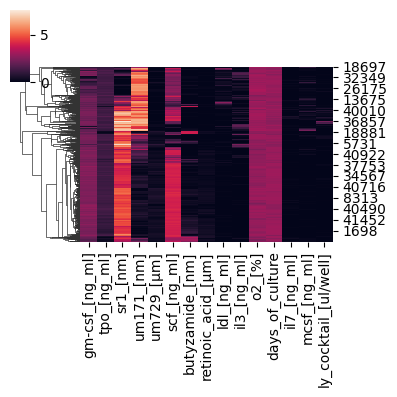

In [29]:
g = sns.clustermap(erypro_prot, figsize=(4,4), row_cluster=True, col_cluster=False)

In [30]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'EryPro_prop': erypro_prop.values
}, index=erypro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['EryPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
4        0.160531  14961
1        0.104364   5311
3        0.087716   3257
2        0.080377     89
5        0.052379      1
       cluster  EryPro_prop
16530        4     0.288063
21830        4     0.287189
17830        4     0.285933
17880        4     0.285802
16280        4     0.285728
...        ...          ...
41676        4     0.050356
37776        4     0.050324
37526        4     0.050313
3926         4     0.050160
15937        4     0.050041

[14961 rows x 2 columns]


In [31]:
erypro_cl1 = erypro_filtered.loc[cluster_df[cluster_df.cluster==1].index]
erypro_cl1 = erypro_cl1.sort_values(by="EryPro_prop").head(3)
erypro_cl1.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
4751,3.655769,3.027298,0.000000,394.53995,0.327938,12.036127,0.000000,0.000000,0.217321,0.276635,23.820713,17.760805,0.065321,0.253981,0.026478
3251,3.635464,3.030597,0.000000,391.80480,0.330774,12.031043,0.000000,0.000000,0.217485,0.279559,23.807266,17.759691,0.066233,0.253791,0.026545
22978,3.174669,1.147362,0.351956,168.06800,0.237378,2.416624,5.805716,0.099731,0.160952,0.000000,15.289507,15.794695,0.000000,1.055872,0.299666


In [32]:
erypro_cl2 = erypro_filtered.loc[cluster_df[cluster_df.cluster==2].index]
erypro_cl2 = erypro_cl2.sort_values(by="EryPro_prop").head(3)
erypro_cl2.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
25911,2.452066,0.128115,12.474174,362.37933,0.002436,1.062091,45.92144,0.019964,0.066854,0.000000,17.941792,13.300692,0.096262,0.115125,0.330165
24361,2.517532,0.117906,13.435519,369.80563,0.002529,1.039585,46.98255,0.018837,0.062814,0.000000,17.984007,13.273665,0.095869,0.112130,0.332058
30126,8.129075,0.091374,202.568850,705.51520,0.000000,0.264681,105.61821,0.046787,0.090721,0.302934,21.651049,12.295095,0.040446,0.167756,0.000000


In [33]:
erypro_cl3 = erypro_filtered.loc[cluster_df[cluster_df.cluster==3].index]
erypro_cl3 = erypro_cl3.sort_values(by="EryPro_prop").head(3)
erypro_cl3.loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
27630,10.174850,2.667546,225.16399,885.16223,0.089084,37.434402,0.000000,0.108109,0.000000,3.271883,17.856955,14.557993,0.000000,0.0,0.000000
30683,7.704694,2.780124,301.79025,961.98380,0.000000,52.396492,0.000000,0.000000,0.031462,0.377999,14.076035,15.326775,0.000000,0.0,0.030052
27420,7.394973,2.870264,702.37494,396.31836,0.262734,0.000000,0.012074,0.078591,0.000000,8.894323,15.855492,19.068390,0.151268,0.0,0.347449
